# **Frequency Domain Filters**
Frequency domain filters transform images into the frequency domain using the Fourier Transform to manipulate spectral components, offering a powerful approach to image processing distinct from spatial domain techniques. By operating on frequency components, these filters excel in tasks like periodic noise reduction, efficient convolution, and selective feature enhancement. This report, aligned with Digital Image Processing (4th Edition) by Gonzalez and Woods, provides a detailed exploration of lowpass, highpass,
and selective filters from a research perspective, emphasizing their theoretical foundations, practical applications, and ongoing research challenges.

### **Why Necessary**
Frequency domain filters are critical in research and applications for:
* `Periodic Noise Reduction`: Essential for suppressing structured noise in domains
like surveillance and satellite imagery, where periodic interference is common.
* `Efficient Convolution`: Fast Fourier Transform (FFT) enables rapid processing of
large kernels, critical for real-time systems and large-scale image analysis.
* `Feature Enhancement`: Highpass filters amplify edges and fine details, supporting
advanced tasks like object detection in defense and medical diagnostics.
* `Preprocessing for Machine Learning`: Facilitates segmentation, classification, and
feature extraction by isolating relevant frequency bands.
* `Versatility Across Domains`: Applicable to grayscale, color, and hyperspectral images, supporting diverse fields like astronomy and biomedical imaging.

### **Types of Frequency Domain Filters**
Frequency domain filters are categorized based on their frequency response, each addressing specific research and application needs:
* `Lowpass Filters`: Attenuate high-frequency components to smooth images, reducing noise while preserving global structure.
* `Highpass Filters`: Amplify high-frequency components to enhance edges and fine details, critical for feature detection.

* `Bandreject Filters`: Suppress specific frequency bands to remove periodic noise, such as interference patterns.

* `Bandpass Filters`: Pass specific frequency bands to isolate features like textures, useful in specialized applications.

* `Notch Filters`: Target specific frequency points for precise noise removal, particularly in structured noise scenarios.

* `Homomorphic Filters`: Separate illumination and reflectance components to enhance contrast or detail, addressing uneven lighting.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

%matplotlib inline

## **Lowpass Frequency Domain Filters**
Lowpass filters attenuate high-frequency components, such as noise or sharp edges, to produce smoother images while preserving low-frequency content like overall structure.
They are foundational in preprocessing for applications requiring noise reduction, such as medical imaging, remote sensing, and computer vision. Research focuses on optimizing
noise suppression, minimizing artifacts, and ensuring computational efficiency for realtime systems.


### **Ideal Lowpass Filter**
The Ideal Lowpass Filter sharply attenuates frequencies beyond a specified cutoff, effectively smoothing images by removing high-frequency noise and edges. Its abrupt cutoff
makes it a theoretical baseline but leads to ringing artifacts, limiting practical use. Research interests include:

* Theoretical Analysis: Examining the impact of sharp frequency cutoffs on image quality and artifact generation.
* Benchmarking: Serving as a reference for comparing advanced lowpass filters in terms of noise reduction and edge blurring.
* Denoising Applications: Evaluated in medical imaging (e.g., MRI/CT denoising) to assess trade-offs between noise removal and loss of diagnostic details.
* Artifact Mitigation: Investigating hybrid spatial-frequency methods to reduce ringing artifacts.
* Computational Simplicity: Analyzing its straightforward implementation versus limitations in real-world scenarios.

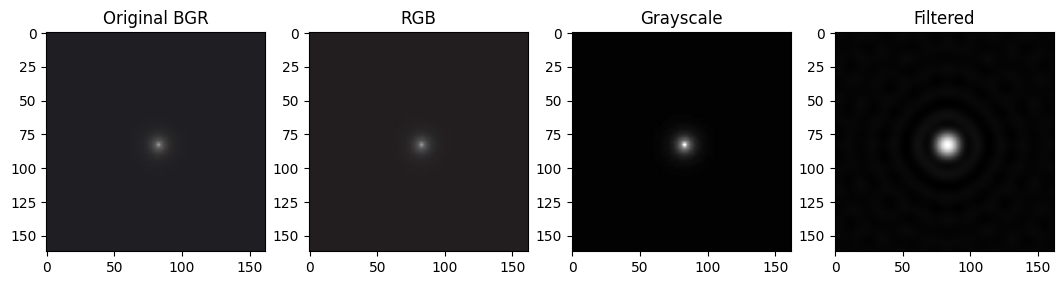

In [104]:
#   Ideal Filter code

image_path = 'dot.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Compute 2D FFT
f = np.fft.fft2(img_gray)
fshift = np.fft.fftshift(f)

# Create Ideal Lowpass Filter
rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2
D0 = 10
H = np.zeros((rows, cols), dtype=np.float32)
for u in range(rows):
    for v in range(cols):
        D = np.sqrt((u - crow)**2 + (v - ccol)**2)
        if D <= D0:
            H[u, v] = 0.8

# Apply filter and inverse FFT
fshift_filtered = fshift * H
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Save images
os.makedirs('Ideal_Lowpass', exist_ok=True)
cv2.imwrite('Ideal_Lowpass/original_bgr.jpg', img_bgr)
cv2.imwrite('Ideal_Lowpass/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Ideal_Lowpass/grayscale.jpg', img_gray)
cv2.imwrite('Ideal_Lowpass/filtered.jpg', img_filtered)

# Display images
plt.figure(figsize=(13, 5))
plt.subplot(141); plt.imshow(img_bgr); plt.title('Original BGR');
plt.subplot(142); plt.imshow(img_rgb); plt.title('RGB');
plt.subplot(143); plt.imshow(img_gray, cmap='gray'); plt.title('Grayscale');
plt.subplot(144); plt.imshow(img_filtered, cmap='gray'); plt.title('Filtered');
plt.show()

### **Butterworth Lowpass Filter**
The Butterworth Lowpass Filter provides a smoother transition between passed and attenuated frequencies, reducing ringing artifacts compared to the ideal filter. It is parameterized by cutoff frequency and order, allowing control over transition steepness.

**Research focuses on**:

* Flexible Noise Suppression: Studying its ability to balance noise reduction and detail preservation through adjustable order parameters.
* Parameter Optimization: Investigating optimal cutoff and order settings for applications like satellite imagery or medical diagnostics.
* Comparative Performance: Comparing its effectiveness against Gaussian and ideal filters in artifact reduction and computational cost.
* Real-Time Processing: Evaluating its suitability for real-time systems due to efficient FFT-based implementation.
* AI Preprocessing: Exploring its role in preparing images for deep learning tasks like classification and segmentation.

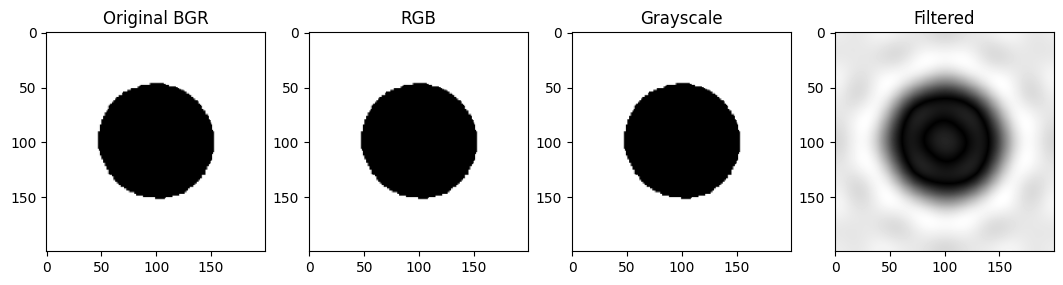

In [86]:
# Butterworth Lowpass Filter code

image_path = 'circle.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Compute 2D FFT
f = np.fft.fft2(img_gray)
fshift = np.fft.fftshift(f)

# Create Butterworth Lowpass Filter
rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2
D0 = 5
n = 80
u = np.arange(-crow, rows - crow)
v = np.arange(-ccol, cols - ccol)
U, V = np.meshgrid(v, u)
D = np.sqrt(U**2 + V**2)
H = 1 / (1 + (D / D0)**(2 * n))

# Apply filter and inverse FFT
fshift_filtered = fshift * H
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Save images
os.makedirs('Butterworth_Lowpass', exist_ok=True)
cv2.imwrite('Butterworth_Lowpass/original_bgr.jpg', img_bgr)
cv2.imwrite('Butterworth_Lowpass/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Butterworth_Lowpass/grayscale.jpg', img_gray)
cv2.imwrite('Butterworth_Lowpass/filtered.jpg', img_filtered)

# Display images
plt.figure(figsize=(13, 5))
plt.subplot(141); plt.imshow(img_bgr); plt.title('Original BGR');
plt.subplot(142); plt.imshow(img_rgb); plt.title('RGB');
plt.subplot(143); plt.imshow(img_gray, cmap='gray'); plt.title('Grayscale');
plt.subplot(144); plt.imshow(img_filtered, cmap='gray'); plt.title('Filtered');
plt.show()

### **Gaussian Lowpass Filter**
The Gaussian Lowpass Filter uses a smooth, bell-shaped transfer function to gradually
attenuate high frequencies, minimizing ringing artifacts. It is highly effective for denoising while preserving structural details. Research includes:

* Optimized Denoising: Evaluating its effectiveness in noise suppression across diverse image types, such as natural or medical images.
* Parameter Sensitivity: Studying the impact of the Gaussian spread parameter on filter performance and image quality.
* Artifact-Free Smoothing: Analyzing its minimal artifact generation compared to ideal and Butterworth filters.
* Deep Learning Integration: Exploring its use in preprocessing for convolutional neural networks to enhance feature extraction.
* Robustness Across Datasets: Assessing performance on noisy or low-contrast images in real-time applications.

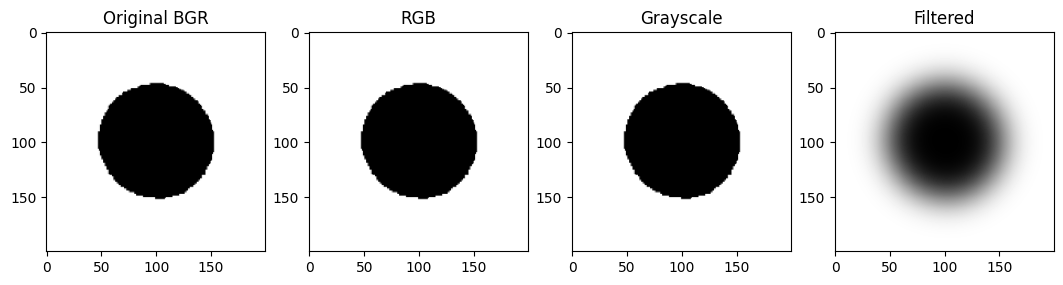

In [51]:
# Gaussian lowpass Filter code

image_path = 'circle.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Compute 2D FFT
f = np.fft.fft2(img_gray)
fshift = np.fft.fftshift(f)

# Create Gaussian Lowpass Filter
rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2
sigma = 2.25
u = np.arange(-crow, rows - crow)
v = np.arange(-ccol, cols - ccol)
U, V = np.meshgrid(v, u)
D = np.sqrt(U**2 + V**2)
H = np.exp(-(D**2) / (2 * sigma**2))

# Apply filter and inverse FFT
fshift_filtered = fshift * H
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Save images
os.makedirs('Gaussian_Lowpass', exist_ok=True)
cv2.imwrite('Gaussian_Lowpass/original_bgr.jpg', img_bgr)
cv2.imwrite('Gaussian_Lowpass/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Gaussian_Lowpass/grayscale.jpg', img_gray)
cv2.imwrite('Gaussian_Lowpass/filtered.jpg', img_filtered)

# Display images
plt.figure(figsize=(13, 5))
plt.subplot(141); plt.imshow(img_bgr); plt.title('Original BGR');
plt.subplot(142); plt.imshow(img_rgb); plt.title('RGB');
plt.subplot(143); plt.imshow(img_gray, cmap='gray'); plt.title('Grayscale');
plt.subplot(144); plt.imshow(img_filtered, cmap='gray'); plt.title('Filtered');
plt.show()

## **Highpass Frequency Domain Filters**
Highpass filters amplify high-frequency components, such as edges and fine details, to enhance image sharpness and support feature extraction. They are critical for object detection and image analysis but can amplify noise, posing research challenges in balancing enhancement and noise control.


### **Ideal Highpass Filter**
The Ideal Highpass Filter passes frequencies above a specified cutoff, enhancing edges but often introducing ringing artifacts and amplifying noise. It serves as a theoretical model for high-frequency enhancement. Research interests include:
* Edge Enhancement Analysis: Studying its role in highlighting edges for object detection in surveillance and autonomous systems.
* Artifact Mitigation: Investigating techniques to reduce ringing artifacts, such as hybrid filtering methods.
* Noise Amplification Control: Exploring strategies to suppress noise amplification, a key limitation in highpass filtering.
* Feature Extraction: Evaluating its effectiveness in preprocessing for edge-based segmentation and computer vision tasks.
* Comparative Performance: Comparing sharpness and noise trade-offs against Butterworth and Gaussian highpass filters.

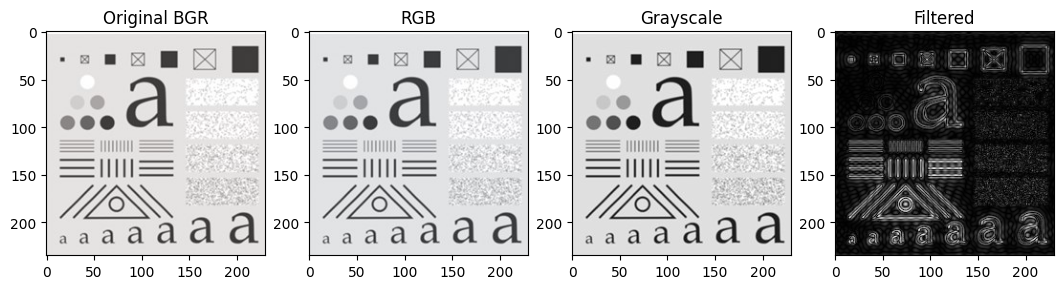

In [70]:
# Ideal High Pass Filter code

image_path = 'img.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Compute 2D FFT
f = np.fft.fft2(img_gray)
fshift = np.fft.fftshift(f)

# Create Ideal Highpass Filter
rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2
D0 = 30
H = np.ones((rows, cols), dtype=np.float32)
for u in range(rows):
    for v in range(cols):
        D = np.sqrt((u - crow)**2 + (v - ccol)**2)
        if D <= D0:
            H[u, v] = 0.0

# Apply filter and inverse FFT
fshift_filtered = fshift * H
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Save images
os.makedirs('Ideal_Highpass', exist_ok=True)
cv2.imwrite('Ideal_Highpass/original_bgr.jpg', img_bgr)
cv2.imwrite('Ideal_Highpass/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Ideal_Highpass/grayscale.jpg', img_gray)
cv2.imwrite('Ideal_Highpass/filtered.jpg', img_filtered)

# Display images
plt.figure(figsize=(13, 5))
plt.subplot(141); plt.imshow(img_bgr); plt.title('Original BGR');
plt.subplot(142); plt.imshow(img_rgb); plt.title('RGB');
plt.subplot(143); plt.imshow(img_gray, cmap='gray'); plt.title('Grayscale');
plt.subplot(144); plt.imshow(img_filtered, cmap='gray'); plt.title('Filtered');
plt.show()

### **Butterworth Highpass Filter**
The Butterworth Highpass Filter offers a smoother frequency transition than the ideal filter, reducing artifacts. Its order parameter controls transition steepness, making it adaptable for various applications. Research focuses on:
* Controlled Edge Enhancement: Analyzing its ability to enhance edges with reduced artifacts through order tuning.
* Noise Management: Investigating methods to minimize noise amplification while
maintaining sharpness.
* Application-Specific Optimization: Studying optimal parameters for tasks like medical diagnostics or autonomous navigation.
* Real-Time Feasibility: Evaluating computational efficiency for real-time edge enhancement in embedded systems.
* AI Integration: Exploring its role in preprocessing for feature enhancement in neural network-based tasks.

C:\Users\Mjain\AppData\Local\Temp\ipykernel_14772\1135507545.py:23: RuntimeWarning: divide by zero encountered in divide
  H = 1 / (1 + (D0 / D)**(2 * n))


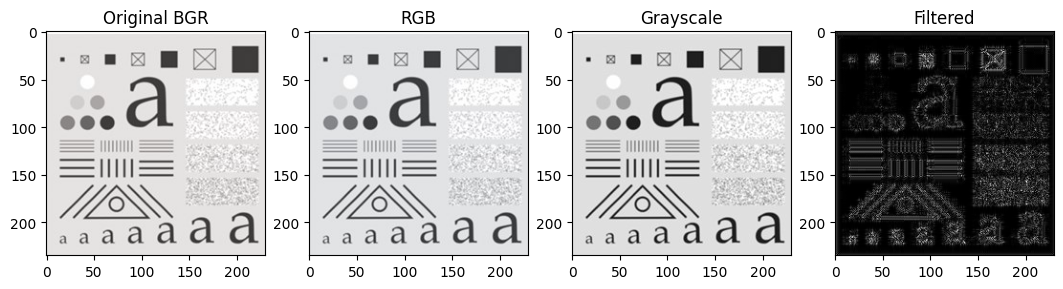

In [65]:
# Butterworth Highpass Filter code

image_path = 'img.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Compute 2D FFT
f = np.fft.fft2(img_gray)
fshift = np.fft.fftshift(f)

# Create Butterworth Highpass Filter
rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2
D0 = 160
n = 2
u = np.arange(-crow, rows - crow)
v = np.arange(-ccol, cols - ccol)
U, V = np.meshgrid(v, u)
D = np.sqrt(U**2 + V**2)
H = 1 / (1 + (D0 / D)**(2 * n))

# Apply filter and inverse FFT
fshift_filtered = fshift * H
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Save images
os.makedirs('Butterworth_Highpass', exist_ok=True)
cv2.imwrite('Butterworth_Highpass/original_bgr.jpg', img_bgr)
cv2.imwrite('Butterworth_Highpass/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Butterworth_Highpass/grayscale.jpg', img_gray)
cv2.imwrite('Butterworth_Highpass/filtered.jpg', img_filtered)

# Display images
plt.figure(figsize=(13, 5))
plt.subplot(141); plt.imshow(img_bgr); plt.title('Original BGR'); 
plt.subplot(142); plt.imshow(img_rgb); plt.title('RGB'); 
plt.subplot(143); plt.imshow(img_gray, cmap='gray'); plt.title('Grayscale'); 
plt.subplot(144); plt.imshow(img_filtered, cmap='gray'); plt.title('Filtered'); 
plt.show()

### **Gaussian Highpass Filter**
The Gaussian Highpass Filter enhances high frequencies with a smooth transfer function, minimizing artifacts compared to the ideal filter. It is widely studied for its practicalv advantages in edge enhancement. Research includes:
* Artifact Reduction: Analyzing smoother transitions to minimize ringing and noise amplification.
* Edge Enhancement Optimization: Studying effectiveness in enhancing edges for medical diagnostics and computer vision.
* Parameter Sensitivity: Investigating the impact of the Gaussian spread parameter on edge preservation and noise control.
* Deep Learning Preprocessing: Exploring its use in enhancing features for object recognition and classification tasks.
* Robustness Across Datasets: Evaluating performance on low-contrast or noisy images in diverse applications.

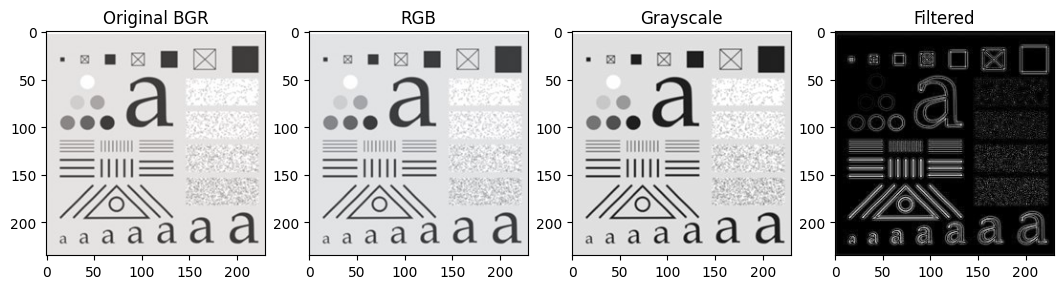

In [71]:
# Gaussian High Pass Filter code

image_path = 'img.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Compute 2D FFT
f = np.fft.fft2(img_gray)
fshift = np.fft.fftshift(f)

# Create Gaussian Highpass Filter
rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2
sigma = 30
u = np.arange(-crow, rows - crow)
v = np.arange(-ccol, cols - ccol)
U, V = np.meshgrid(v, u)
D = np.sqrt(U**2 + V**2)
H = 1 - np.exp(-(D**2) / (2 * sigma**2))

# Apply filter and inverse FFT
fshift_filtered = fshift * H
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Save images
os.makedirs('Gaussian_Highpass', exist_ok=True)
cv2.imwrite('Gaussian_Highpass/original_bgr.jpg', img_bgr)
cv2.imwrite('Gaussian_Highpass/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Gaussian_Highpass/grayscale.jpg', img_gray)
cv2.imwrite('Gaussian_Highpass/filtered.jpg', img_filtered)

# Display images
plt.figure(figsize=(13, 5))
plt.subplot(141); plt.imshow(img_bgr); plt.title('Original BGR');
plt.subplot(142); plt.imshow(img_rgb); plt.title('RGB');
plt.subplot(143); plt.imshow(img_gray, cmap='gray'); plt.title('Grayscale');
plt.subplot(144); plt.imshow(img_filtered, cmap='gray'); plt.title('Filtered');
plt.show()

## **Bandreject Frequency Domain Filters**
Bandreject filters suppress frequencies within a specific band while passing others, ideal for removing periodic noise, such as interference patterns in satellite or medical imagery.
Research focuses on precision in noise removal and minimizing unintended effects on image content.

### **Ideal Bandreject Filter**
The Ideal Bandreject Filter sharply blocks a specific frequency band, effectively removing
periodic noise but prone to ringing artifacts due to abrupt cutoffs. Research interests include:
* Periodic Noise Removal: Studying its ability to eliminate structured noise in satellite imagery or medical scans.
* Artifact Analysis: Investigating ringing artifacts and developing mitigation strategies, such as hybrid filtering.
* Theoretical Benchmarking: Using it as a baseline to compare with smoother bandreject filters.
* Application in Imaging Systems: Evaluating effectiveness in removing interference in medical and remote sensing data.
* Computational Simplicity: Analyzing straightforward implementation versus practical limitations.

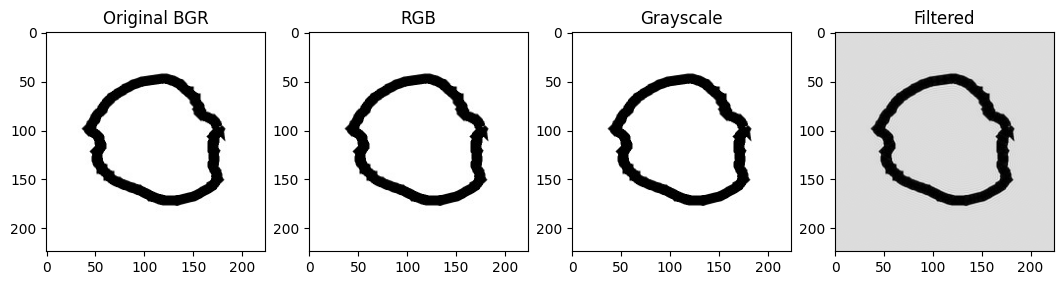

In [ ]:
# Ideal Bandreject Filter code

image_path = 'circle1.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Compute 2D FFT
f = np.fft.fft2(img_gray)
fshift = np.fft.fftshift(f)

# Create Ideal Bandreject Filter
rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2
D0 = 128
W = 60 # Bandwidth
H = np.ones((rows, cols), dtype=np.float32)
for u in range(rows):
    for v in range(cols):
        D = np.sqrt((u - crow)**2 + (v - ccol)**2)
        if D0 - W/2 <= D <= D0 + W/2:
            H[u, v] = 0.0

# Apply filter and inverse FFT
fshift_filtered = fshift * H
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Save images
os.makedirs('Ideal_Bandreject', exist_ok=True)
cv2.imwrite('Ideal_Bandreject/original_bgr.jpg', img_bgr)
cv2.imwrite('Ideal_Bandreject/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Ideal_Bandreject/grayscale.jpg', img_gray)
cv2.imwrite('Ideal_Bandreject/filtered.jpg', img_filtered)

# Display images
plt.figure(figsize=(13, 5))
plt.subplot(141); plt.imshow(img_bgr); plt.title('Original BGR');
plt.subplot(142); plt.imshow(img_rgb); plt.title('RGB');
plt.subplot(143); plt.imshow(img_gray, cmap='gray'); plt.title('Grayscale');
plt.subplot(144); plt.imshow(img_filtered, cmap='gray'); plt.title('Filtered');
plt.show()

### **Butterworth Bandreject Filter**
The Butterworth Bandreject Filter provides a smoother transition, reducing artifacts compared to the ideal filter. It is parameterized by center frequency, bandwidth, and order. Research focuses on:
* Noise Suppression Precision: Studying its ability to target specific frequency bands with minimal artifacts.
* Parameter Optimization: Investigating optimal bandwidth and order settings for applications like surveillance imaging.
* Comparative Performance: Comparing effectiveness against Gaussian and ideal bandreject filters.
* Real-Time Applications: Evaluating suitability for real-time noise removal in imaging systems.
* AI Preprocessing: Exploring its role in preparing noisy datasets for machine learning tasks.

C:\Users\Mjain\AppData\Local\Temp\ipykernel_14772\2680906274.py:24: RuntimeWarning: divide by zero encountered in divide
  H = 1 / (1 + ((D * W) / (D**2 - D0**2))**(2 * n))


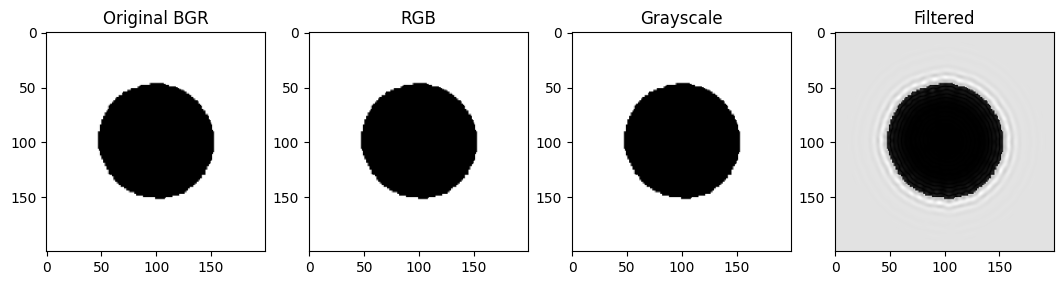

In [15]:
# Butterworth Bandreject Filter code

image_path = 'circle.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Compute 2D FFT
f = np.fft.fft2(img_gray)
fshift = np.fft.fftshift(f)

# Create Butterworth Bandreject Filter
rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2
D0 = 30
W = 10
n = 2
u = np.arange(-crow, rows - crow)
v = np.arange(-ccol, cols - ccol)
U, V = np.meshgrid(v, u)
D = np.sqrt(U**2 + V**2)
H = 1 / (1 + ((D * W) / (D**2 - D0**2))**(2 * n))

# Apply filter and inverse FFT
fshift_filtered = fshift * H
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Save images
os.makedirs('Butterworth_Bandreject', exist_ok=True)
cv2.imwrite('Butterworth_Bandreject/original_bgr.jpg', img_bgr)
cv2.imwrite('Butterworth_Bandreject/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Butterworth_Bandreject/grayscale.jpg', img_gray)
cv2.imwrite('Butterworth_Bandreject/filtered.jpg', img_filtered)

# Display images
plt.figure(figsize=(13, 5))
plt.subplot(141); plt.imshow(img_bgr); plt.title('Original BGR');
plt.subplot(142); plt.imshow(img_rgb); plt.title('RGB');
plt.subplot(143); plt.imshow(img_gray, cmap='gray'); plt.title('Grayscale');
plt.subplot(144); plt.imshow(img_filtered, cmap='gray'); plt.title('Filtered');
plt.show()

### **Gaussian Bandreject Filter**
The Gaussian Bandreject Filter uses a smooth transfer function to suppress a frequency band, minimizing artifacts and preserving image quality. Research includes:
* Artifact-Free Noise Removal: Analyzing minimal artifact generation compared to ideal and Butterworth filters.
* Noise Suppression Effectiveness: Studying its ability to remove periodic noise in satellite and medical imagery.
* Parameter Tuning: Investigating the impact of the Gaussian spread parameter on noise removal and image quality.
* Application Versatility: Evaluating performance across diverse domains, such as astronomy and industrial inspection.
* AI Integration: Exploring its use in preprocessing for deep learning-based noise reduction.

C:\Users\Mjain\AppData\Local\Temp\ipykernel_14772\4054466874.py:24: RuntimeWarning: divide by zero encountered in divide
  H = 1 - np.exp(-((D**2 - D0**2)/(D * W))**2 / (2 * sigma**2))


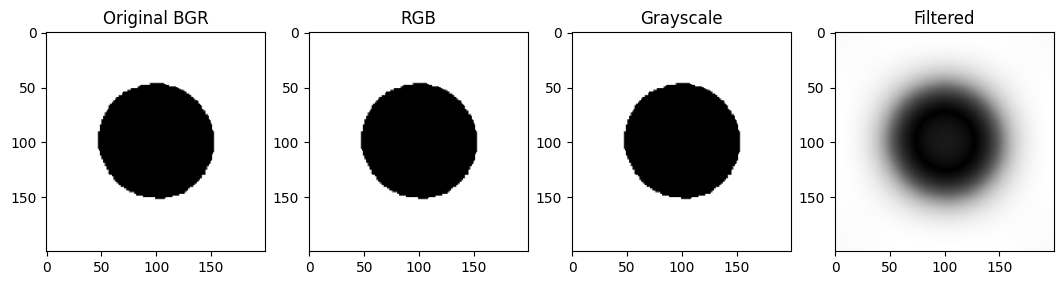

In [16]:
# Gaussian Bandreject Filter code

image_path = 'circle.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Compute 2D FFT
f = np.fft.fft2(img_gray)
fshift = np.fft.fftshift(f)

# Create Gaussian Bandreject Filter
rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2
D0 = 30
W = 10
sigma = 30
u = np.arange(-crow, rows - crow)
v = np.arange(-ccol, cols - ccol)
U, V = np.meshgrid(v, u)
D = np.sqrt(U**2 + V**2)
H = 1 - np.exp(-((D**2 - D0**2)/(D * W))**2 / (2 * sigma**2))

# Apply filter and inverse FFT
fshift_filtered = fshift * H
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Save images
os.makedirs('Gaussian_Bandreject', exist_ok=True)
cv2.imwrite('Gaussian_Bandreject/original_bgr.jpg', img_bgr)
cv2.imwrite('Gaussian_Bandreject/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Gaussian_Bandreject/grayscale.jpg', img_gray)
cv2.imwrite('Gaussian_Bandreject/filtered.jpg', img_filtered)

# Display images
plt.figure(figsize=(13, 5))
plt.subplot(141); plt.imshow(img_bgr); plt.title('Original BGR');
plt.subplot(142); plt.imshow(img_rgb); plt.title('RGB');
plt.subplot(143); plt.imshow(img_gray, cmap='gray'); plt.title('Grayscale');
plt.subplot(144); plt.imshow(img_filtered, cmap='gray'); plt.title('Filtered');
plt.show()

## **Bandpass Frequency Domain Filters**
Bandpass filters pass frequencies within a specific band while attenuating others, useful for isolating features like textures or specific frequency components in specialized applications. Research focuses on precision in feature extraction and robustness in noisy environments.


### **Ideal Bandpass Filter**
The Ideal Bandpass Filter passes a specific frequency band with sharp cutoffs, suitable for isolating features but susceptible to ringing artifacts. Research interests include:
* Feature Isolation: Studying its ability to extract specific frequency components, such as textures in material analysis.
* Artifact Analysis: Investigating ringing artifacts and mitigation strategies for practical applications.
* Theoretical Benchmarking: Using it as a baseline for comparing smoother bandpass filters.
* Texture Analysis Applications: Evaluating effectiveness in isolating texture features for computer vision tasks.
* Computational Challenges: Analyzing implementation simplicity versus limitations in real-world scenarios.

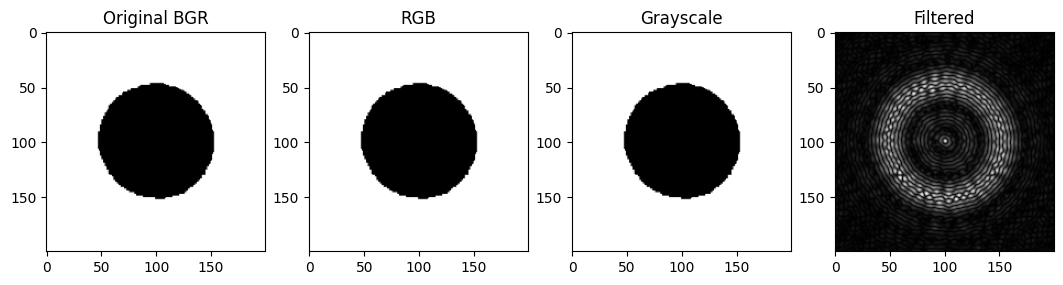

In [ ]:
# Idea Bandpass Filter code

image_path = 'circle.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Compute 2D FFT
f = np.fft.fft2(img_gray)
fshift = np.fft.fftshift(f)

# Create Ideal Bandpass Filter
rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2
D0 = 30
W = 10
H = np.zeros((rows, cols), dtype=np.float32)
for u in range(rows):
    for v in range(cols):
        D = np.sqrt((u - crow)**2 + (v - ccol)**2)
        if D0 - W/2 <= D <= D0 + W/2:
            H[u, v] = 1.0

# Apply filter and inverse FFT
fshift_filtered = fshift * H
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Save images
os.makedirs('Ideal_Bandpass', exist_ok=True)
cv2.imwrite('Ideal_Bandpass/original_bgr.jpg', img_bgr)
cv2.imwrite('Ideal_Bandpass/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Ideal_Bandpass/grayscale.jpg', img_gray)
cv2.imwrite('Ideal_Bandpass/filtered.jpg', img_filtered)

# Display images
plt.figure(figsize=(13, 5))
plt.subplot(141); plt.imshow(img_bgr); plt.title('Original BGR');
plt.subplot(142); plt.imshow(img_rgb); plt.title('RGB');
plt.subplot(143); plt.imshow(img_gray, cmap='gray'); plt.title('Grayscale');
plt.subplot(144); plt.imshow(img_filtered, cmap='gray'); plt.title('Filtered');
plt.show()

### **Butterworth Bandpass Filter**
The Butterworth Bandpass Filter offers smoother transitions, reducing artifacts compared to the ideal filter. It is parameterized by center frequency, bandwidth, and order.
Research focuses on:
* Feature Extraction Precision: Studying its ability to isolate specific frequency bands with controlled artifacts.
* Parameter Optimization: Investigating optimal bandwidth and order settings for texture analysis or feature extraction.
* Comparative Performance: Comparing effectiveness against Gaussian and ideal bandpass filters.
* Real-Time Feasibility: Evaluating computational efficiency for real-time feature extraction.
* Machine Learning Integration: Exploring its role in preprocessing for texture-based classification tasks

C:\Users\Mjain\AppData\Local\Temp\ipykernel_14772\1141622923.py:24: RuntimeWarning: divide by zero encountered in divide
  H = 1 - 1 / (1 + ((D * W) / (D**2 - D0**2))**(2 * n))


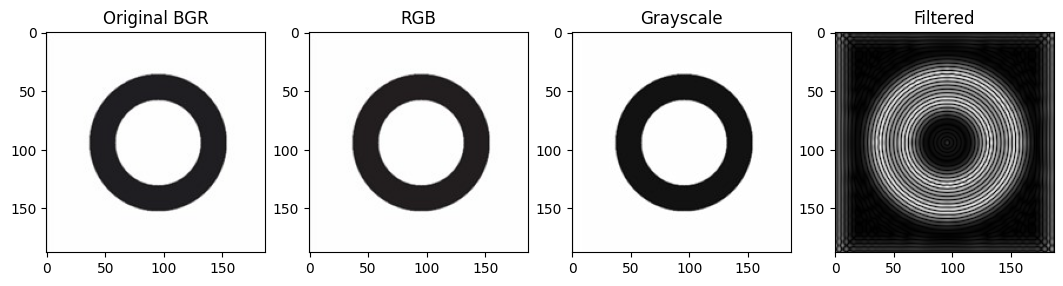

In [163]:
# Butterworth Bandpass Filter code

image_path = 'circle2.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Compute 2D FFT
f = np.fft.fft2(img_gray)
fshift = np.fft.fftshift(f)

# Create Butterworth Bandpass Filter
rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2
D0 = 30
W = 10
n = 2
u = np.arange(-crow, rows - crow)
v = np.arange(-ccol, cols - ccol)
U, V = np.meshgrid(v, u)
D = np.sqrt(U**2 + V**2)
H = 1 - 1 / (1 + ((D * W) / (D**2 - D0**2))**(2 * n))

# Apply filter and inverse FFT
fshift_filtered = fshift * H
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Save images
os.makedirs('Butterworth_Bandpass', exist_ok=True)
cv2.imwrite('Butterworth_Bandpass/original_bgr.jpg', img_bgr)
cv2.imwrite('Butterworth_Bandpass/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Butterworth_Bandpass/grayscale.jpg', img_gray)
cv2.imwrite('Butterworth_Bandpass/filtered.jpg', img_filtered)

# Display images
plt.figure(figsize=(13, 5))
plt.subplot(141); plt.imshow(img_bgr); plt.title('Original BGR');
plt.subplot(142); plt.imshow(img_rgb); plt.title('RGB');
plt.subplot(143); plt.imshow(img_gray, cmap='gray'); plt.title('Grayscale');
plt.subplot(144); plt.imshow(img_filtered, cmap='gray'); plt.title('Filtered');
plt.show()

### **Gaussian Bandpass Filter**
The Gaussian Bandpass Filter uses a smooth transfer function to isolate a frequency band, minimizing artifacts. Research includes:
* Artifact-Free Feature Isolation: Analyzing minimal artifact generation compared to ideal and Butterworth filters.
* Texture Analysis Effectiveness: Studying its ability to isolate texture features in material or medical imaging.
* Parameter Sensitivity: Investigating the impact of the Gaussian spread parameter on feature extraction.
* Robustness in Noisy Environments: Evaluating performance on noisy datasets in computer vision applications.
* AI Preprocessing: Exploring its use in preparing images for deep learning-based feature extraction.

C:\Users\Mjain\AppData\Local\Temp\ipykernel_14772\937209581.py:24: RuntimeWarning: divide by zero encountered in divide
  H = np.exp(-((D**2 - D0**2)/(D * W))**2 / (2 * sigma**2))


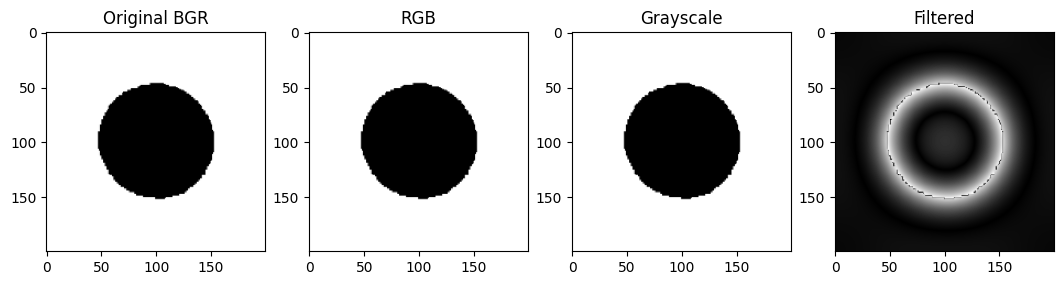

In [165]:
# Gaussian Bandpass Filter code

image_path = 'circle.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Compute 2D FFT
f = np.fft.fft2(img_gray)
fshift = np.fft.fftshift(f)

# Create Gaussian Bandpass Filter
rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2
D0 = 30
W = 10
sigma = 30
u = np.arange(-crow, rows - crow)
v = np.arange(-ccol, cols - ccol)
U, V = np.meshgrid(v, u)
D = np.sqrt(U**2 + V**2)
H = np.exp(-((D**2 - D0**2)/(D * W))**2 / (2 * sigma**2))

# Apply filter and inverse FFT
fshift_filtered = fshift * H
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Save images
os.makedirs('Gaussian_Bandpass', exist_ok=True)
cv2.imwrite('Gaussian_Bandpass/original_bgr.jpg', img_bgr)
cv2.imwrite('Gaussian_Bandpass/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Gaussian_Bandpass/grayscale.jpg', img_gray)
cv2.imwrite('Gaussian_Bandpass/filtered.jpg', img_filtered)

# Display images
plt.figure(figsize=(13, 5))
plt.subplot(141); plt.imshow(img_bgr); plt.title('Original BGR');
plt.subplot(142); plt.imshow(img_rgb); plt.title('RGB');
plt.subplot(143); plt.imshow(img_gray, cmap='gray'); plt.title('Grayscale');
plt.subplot(144); plt.imshow(img_filtered, cmap='gray'); plt.title('Filtered');
plt.show()

## **Notch Frequency Domain Filters**
Notch filters target specific frequency points to remove periodic noise, such as interference patterns in satellite or medical imagery. They are highly precise, affecting only targeted frequencies, and are studied for accuracy and minimal impact on surrounding content.

### **Ideal Notch Filter**
The Ideal Notch Filter suppresses specific frequency points, effectively removing periodic noise but potentially causing minor artifacts due to sharp suppression. Research interests include:
* Precision Noise Removal: Studying its ability to target specific noise frequencies in satellite imagery.
* Artifact Analysis: Investigating minor artifacts caused by sharp suppression and mitigation strategies.
* Theoretical Benchmarking: Using it as a baseline for comparing smoother notch filters.
* Applications in Imaging: Evaluating effectiveness in removing interference in medical and remote sensing data.
* Implementation Simplicity: Analyzing straightforward implementation versus practical limitations.

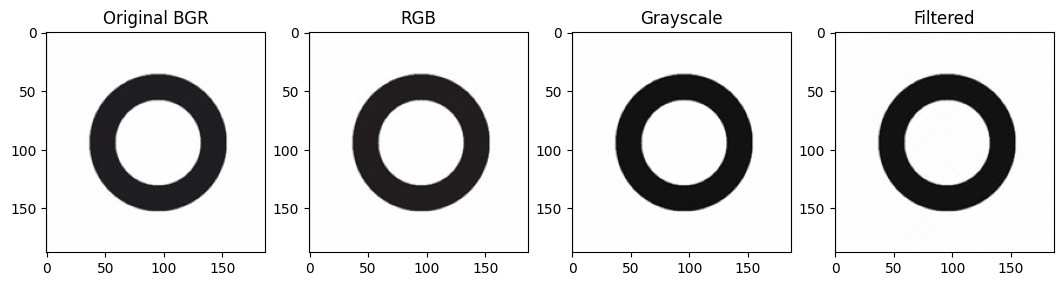

In [25]:
# Ideal Notch Filter code


image_path = 'circle2.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Compute 2D FFT
f = np.fft.fft2(img_gray)
fshift = np.fft.fftshift(f)

# Create Ideal Notch Filter
rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2
H = np.ones((rows, cols), dtype=np.float32)
notch_points = [(crow + 20, ccol + 20), (crow - 20, ccol - 20)]  # Example notch points
for u, v in notch_points:
    H[u, v] = 0
    H[rows - u, cols - v] = 0  # Symmetric pair

# Apply filter and inverse FFT
fshift_filtered = fshift * H
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Save images
os.makedirs('Ideal_Notch', exist_ok=True)
cv2.imwrite('Ideal_Notch/original_bgr.jpg', img_bgr)
cv2.imwrite('Ideal_Notch/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Ideal_Notch/grayscale.jpg', img_gray)
cv2.imwrite('Ideal_Notch/filtered.jpg', img_filtered)

# Display images
plt.figure(figsize=(13, 5))
plt.subplot(141); plt.imshow(img_bgr); plt.title('Original BGR');
plt.subplot(142); plt.imshow(img_rgb); plt.title('RGB');
plt.subplot(143); plt.imshow(img_gray, cmap='gray'); plt.title('Grayscale');
plt.subplot(144); plt.imshow(img_filtered, cmap='gray'); plt.title('Filtered');
plt.show()

### **Butterworth Notch Filter**
The Butterworth Notch Filter provides smoother suppression of specific frequencies, reducing artifacts compared to the ideal filter. It is parameterized by notch frequency and
order. Research focuses on:
* Precise Noise Suppression: Studying its ability to target noise frequencies with minimal artifacts.
* Parameter Optimization: Investigating optimal order and notch width settings for medical or satellite imaging.
* Comparative Performance: Comparing effectiveness against Gaussian and ideal notch filters.
* Adaptive Filtering: Exploring algorithms to automatically detect and suppress noise frequencies.
* Real-Time Applications: Evaluating suitability for real-time noise removal in imaging systems.


C:\Users\Mjain\AppData\Local\Temp\ipykernel_14772\3001983387.py:25: RuntimeWarning: divide by zero encountered in divide
  H *= (1 / (1 + (D0 / D1)**(2 * n))) * (1 / (1 + (D0 / D2)**(2 * n)))


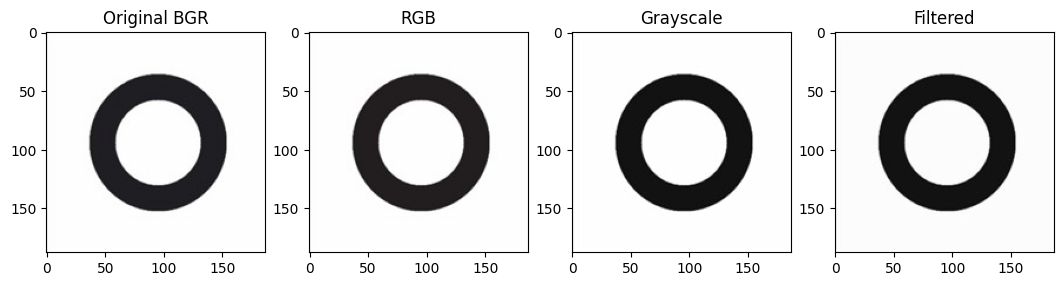

In [182]:

image_path = 'circle2.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Compute 2D FFT
f = np.fft.fft2(img_gray)
fshift = np.fft.fftshift(f)

# Create Butterworth Notch Filter
rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2
D0 = 10
n = 2
H = np.ones((rows, cols), dtype=np.float32)
notch_points = [(crow + 20, ccol + 20), (crow - 20, ccol - 20)]
for u0, v0 in notch_points:
    u = np.arange(-crow, rows - crow)
    v = np.arange(-ccol, cols - ccol)
    U, V = np.meshgrid(v, u)
    D1 = np.sqrt((U - u0)**2 + (V - v0)**2)
    D2 = np.sqrt((U - (rows - u0))**2 + (V - (cols - v0))**2)
    H *= (1 / (1 + (D0 / D1)**(2 * n))) * (1 / (1 + (D0 / D2)**(2 * n)))

# Apply filter and inverse FFT
fshift_filtered = fshift * H
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Save images
os.makedirs('Butterworth_Notch', exist_ok=True)
cv2.imwrite('Butterworth_Notch/original_bgr.jpg', img_bgr)
cv2.imwrite('Butterworth_Notch/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Butterworth_Notch/grayscale.jpg', img_gray)
cv2.imwrite('Butterworth_Notch/filtered.jpg', img_filtered)

# Display images
plt.figure(figsize=(13, 5))
plt.subplot(141); plt.imshow(img_bgr); plt.title('Original BGR');
plt.subplot(142); plt.imshow(img_rgb); plt.title('RGB');
plt.subplot(143); plt.imshow(img_gray, cmap='gray'); plt.title('Grayscale');
plt.subplot(144); plt.imshow(img_filtered, cmap='gray'); plt.title('Filtered');
plt.show()

### **Gaussian Notch Filter**
The Gaussian Notch Filter uses a smooth transfer function to suppress specific frequencies, minimizing artifacts and preserving surrounding content. Research includes:
* Artifact-Free Noise Removal: Analyzing minimal artifact generation compared to ideal and Butterworth filters.
* Noise Suppression Precision: Studying effectiveness in removing periodic noise in satellite and medical imagery.
* Parameter Tuning: Investigating the impact of the Gaussian spread parameter on noise removal and image quality.
* Adaptive Notch Filtering: Exploring automated detection of noise frequencies for dynamic applications.
* Emerging Applications: Evaluating its use in radio astronomy and industrial defect detection.

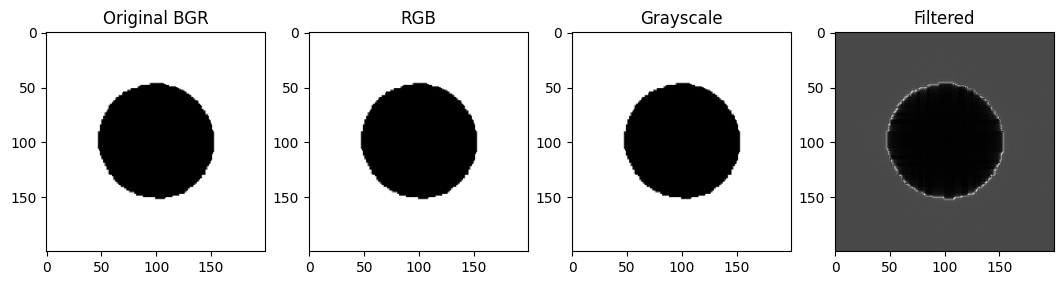

In [192]:
# Gaussain notch Filter code

image_path = 'circle.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Compute 2D FFT
f = np.fft.fft2(img_gray)
fshift = np.fft.fftshift(f)

# Create Gaussian Notch Filter
rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2
sigma = 150
H = np.ones((rows, cols), dtype=np.float32)
notch_points = [(crow + 20, ccol + 20), (crow - 20, ccol - 20)]
for u0, v0 in notch_points:
    u = np.arange(-crow, rows - crow)
    v = np.arange(-ccol, cols - ccol)
    U, V = np.meshgrid(v, u)
    D1 = np.sqrt((U - u0)**2 + (V - v0)**2)
    D2 = np.sqrt((U - (rows - u0))**2 + (V - (cols - v0))**2)
    H *= (1 - np.exp(-(D1**2) / (2 * sigma**2))) * (1 - np.exp(-(D2**2) / (2 * sigma**2)))

# Apply filter and inverse FFT
fshift_filtered = fshift * H
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)

# Save images
os.makedirs('Gaussian_Notch', exist_ok=True)
cv2.imwrite('Gaussian_Notch/original_bgr.jpg', img_bgr)
cv2.imwrite('Gaussian_Notch/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Gaussian_Notch/grayscale.jpg', img_gray)
cv2.imwrite('Gaussian_Notch/filtered.jpg', img_filtered)

# Display images
plt.figure(figsize=(13, 5))
plt.subplot(141); plt.imshow(img_bgr); plt.title('Original BGR');
plt.subplot(142); plt.imshow(img_rgb); plt.title('RGB');
plt.subplot(143); plt.imshow(img_gray, cmap='gray'); plt.title('Grayscale');
plt.subplot(144); plt.imshow(img_filtered, cmap='gray'); plt.title('Filtered');
plt.show()

## **Homomorphic Filtering**
Homomorphic filtering is a specialized frequency domain technique that separates illumination (low-frequency) and reflectance (high-frequency) components to enhance contrast
or detail, particularly in images with uneven lighting. It involves logarithmic transformation, frequency domain filtering, and exponentiation. Research focuses on:
* Illumination Correction: Studying its ability to enhance images with uneven lighting, such as in medical or photographic applications.
* Contrast and Detail Enhancement: Analyzing effectiveness in balancing contrast and detail without introducing artifacts.
* Parameter Optimization: Investigating optimal high- and low-frequency gain settings for specific applications.
* Integration with Other Techniques: Exploring combinations with lowpass or highpass filters for advanced enhancement.
8 Machine Learning Applications: Evaluating its role in preprocessing for deep learning tasks, such as object recognition in low-light conditions.

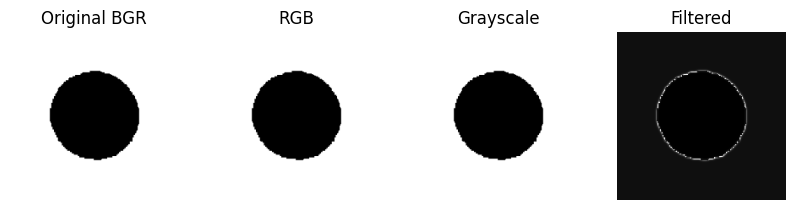

In [195]:
# Homomorphic Filtering code

image_path = 'circle.jpg'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise ValueError('Failed to load image')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Apply logarithmic transform
img_log = np.log1p(img_gray.astype(np.float32))

# Compute 2D FFT
f = np.fft.fft2(img_log)
fshift = np.fft.fftshift(f)

# Create Homomorphic Filter
rows, cols = img_gray.shape
crow, ccol = rows // 2, cols // 2
D0 = 30
gamma_H = 2.0  # High-frequency gain
gamma_L = 0.5  # Low-frequency gain
c = 1.0
u = np.arange(-crow, rows - crow)
v = np.arange(-ccol, cols - ccol)
U, V = np.meshgrid(v, u)
D = np.sqrt(U**2 + V**2)
H = (gamma_H - gamma_L) * (1 - np.exp(-c * (D**2 / D0**2))) + gamma_L

# Apply filter and inverse FFT
fshift_filtered = fshift * H
f_ishift = np.fft.ifftshift(fshift_filtered)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)
img_filtered = np.expm1(img_filtered)  # Inverse log transform
img_filtered = np.clip(img_filtered, 0, 255)

# Save images
os.makedirs('Homomorphic', exist_ok=True)
cv2.imwrite('Homomorphic/original_bgr.jpg', img_bgr)
cv2.imwrite('Homomorphic/original_rgb.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('Homomorphic/grayscale.jpg', img_gray)
cv2.imwrite('Homomorphic/filtered.jpg', img_filtered)

# Display images
plt.figure(figsize=(10, 5))
plt.subplot(141); plt.imshow(img_bgr); plt.title('Original BGR'); plt.axis('off')
plt.subplot(142); plt.imshow(img_rgb); plt.title('RGB'); plt.axis('off')
plt.subplot(143); plt.imshow(img_gray, cmap='gray'); plt.title('Grayscale'); plt.axis('off')
plt.subplot(144); plt.imshow(img_filtered, cmap='gray'); plt.title('Filtered'); plt.axis('off')
plt.show()

## **Practical Applications**
Frequency domain filters have broad applications across research and industry:
* `Medical Imaging`: Lowpass filters denoise MRI/CT scans, highpass filters enhance edges, and homomorphic filters correct uneven lighting for diagnostic clarity.
* `Surveillance and Defense`: Highpass and bandpass filters support object detection and tracking in security footage.
* `Satellite and Remote Sensing`: Notch and bandreject filters remove periodic noise from atmospheric or sensor interference.
* `Computer Vision`: Frequency domain preprocessing enhances features for segmentation, classification, and deep learning tasks.
* `Astronomy`: Selective filters isolate celestial features or remove instrument noise in astronomical imagery.
* `Industrial Inspection`: Bandpass and notch filters aid in defect detection and texture analysis in manufacturing.

## **References**
[1] Gonzalez, R. C., and Woods, R. E. (2018). Digital Image Processing, 4th Edition.
Pearson.